In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

os.makedirs("images", exist_ok=True)

In [2]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print("Train:", x_train.shape, "Test:", x_test.shape)

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1245s 7us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


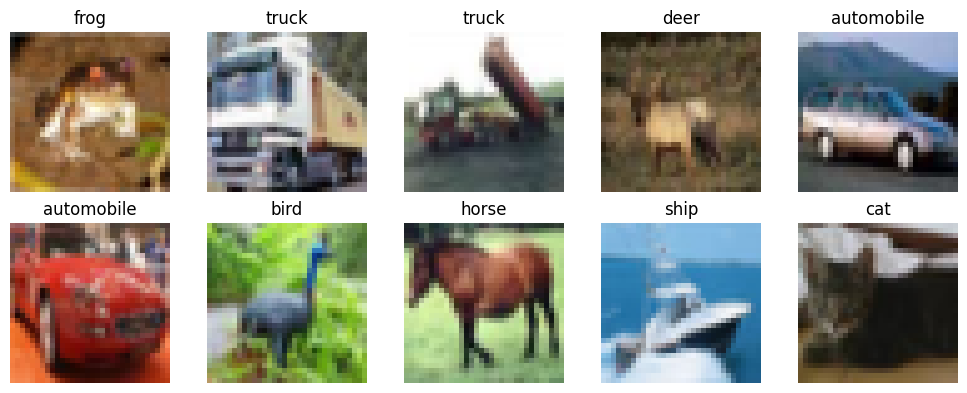

In [4]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.savefig("images/sample_images.png", dpi=300)
plt.show()

In [5]:
# ResNet50

base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
# train

history = model.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.2606 - loss: 2.0209 - val_accuracy: 0.2997 - val_loss: 1.8958
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3175 - loss: 1.8734 - val_accuracy: 0.3214 - val_loss: 1.8839
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3407 - loss: 1.8235 - val_accuracy: 0.3525 - val_loss: 1.7937
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3522 - loss: 1.7870 - val_accuracy: 0.3595 - val_loss: 1.7792
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3625 - loss: 1.7650 - val_accuracy: 0.3529 - val_loss: 1.8057
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3698 - loss: 1.7440 - val_accuracy: 0.3891 - val_loss: 1.7045
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.3766 - loss: 1.7299 - val_accuracy: 0.3476 - val_loss: 1.8452
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3832 - loss:

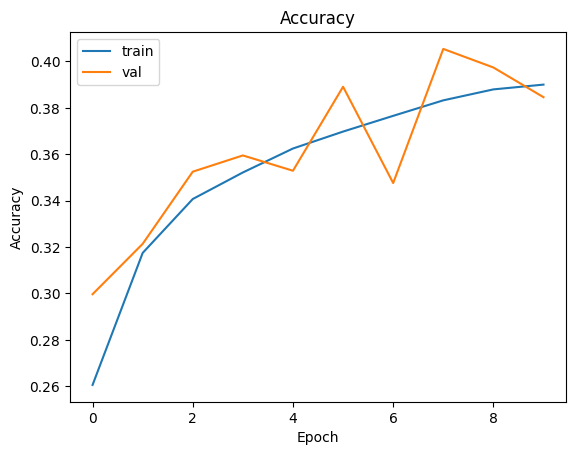

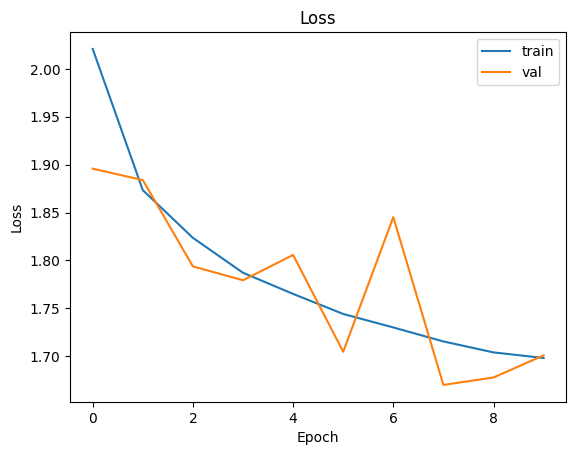

In [8]:
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.savefig("images/accuracy_plot.png", dpi=300)
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.savefig("images/loss_plot.png", dpi=300)
plt.show()

In [10]:
# fine-tuning

base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_ft = model.fit(x_train, y_train_cat, batch_size=32, epochs=5, validation_data=(x_test, y_test_cat))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.3519 - loss: 1.8788 - val_accuracy: 0.2031 - val_loss: 2.5913
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4225 - loss: 1.6269 - val_accuracy: 0.2438 - val_loss: 2.8754
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4523 - loss: 1.5436 - val_accuracy: 0.1121 - val_loss: 5.5940
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4774 - loss: 1.4755 - val_accuracy: 0.1710 - val_loss: 3.4203
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4988 - loss: 1.4262 - val_accuracy: 0.2929 - val_loss: 2.0516


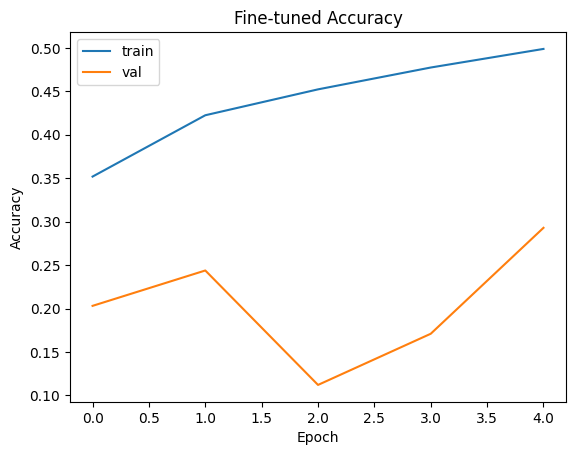

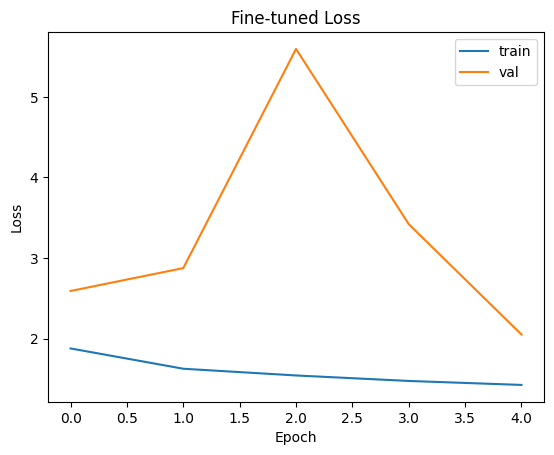

In [11]:
plt.figure()
plt.plot(history_ft.history['accuracy'], label='train')
plt.plot(history_ft.history['val_accuracy'], label='val')
plt.title('Fine-tuned Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.savefig("images/finetune_accuracy_plot.png", dpi=300)
plt.show()

plt.figure()
plt.plot(history_ft.history['loss'], label='train')
plt.plot(history_ft.history['val_loss'], label='val')
plt.title('Fine-tuned Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.savefig("images/finetune_loss_plot.png", dpi=300)
plt.show()

In [12]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

acc = model.evaluate(x_test, y_test_cat)[1]
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print(classification_report(y_true, y_pred, target_names=classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2929 - loss: 2.0516
Accuracy: 0.2928999960422516
Precision: 0.3532449491586785
Recall: 0.29290000000000005
F1-score: 0.2381555589132553
              precision    recall  f1-score   support

    airplane       0.59      0.27      0.37      1000
  automobile       0.23      0.87      0.36      1000
        bird       0.34      0.15      0.20      1000
         cat       0.22      0.03      0.05      1000
        deer       0.00      0.00      0.00      1000
         dog       0.23      0.74      0.34      1000
        frog       0.53      0.02      0.04      1000
       horse       0.46      0.38      0.42      1000
        ship       0.48      0.37      0.42      1000
       truck       0.46      0.11      0.18      1000

    accuracy                           0.29     10000
   macro avg       0.35      0.29      0.24     10000
weighted avg       0.35      0.29      0.24     10000



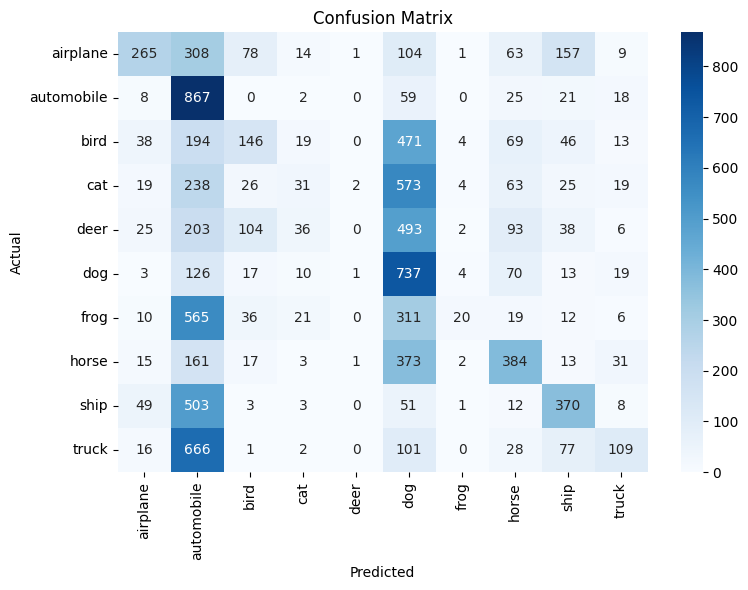

In [13]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300)
plt.show()

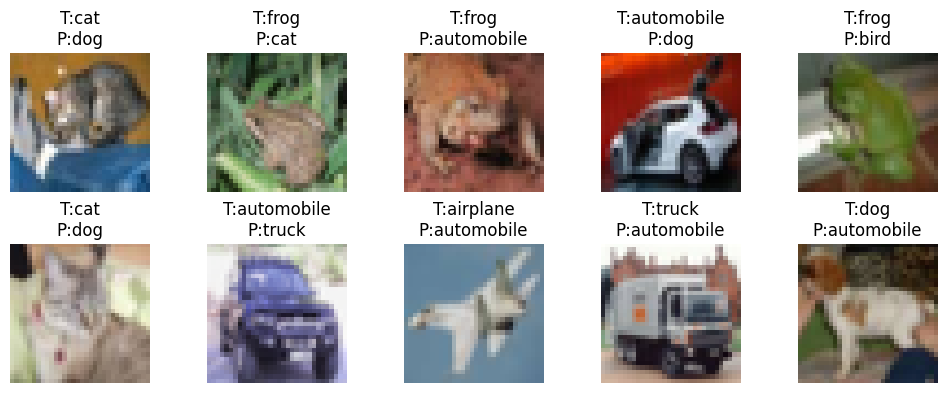

In [14]:
wrong = np.where(y_pred != y_true)[0][:10]
plt.figure(figsize=(10,4))
for i, idx in enumerate(wrong):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{classes[y_true[idx]]}\nP:{classes[y_pred[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig("images/misclassified_images.png", dpi=300)
plt.show()

In [17]:
# hyperparameters

def train_config(lr=0.001, batch=32, opt='adam', dense=256, trainable=False, epochs=3):
    base = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))
    base.trainable = trainable
    if trainable:
        for layer in base.layers[:-10]:
            layer.trainable = False

    m = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(dense, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr) if opt=='adam' else tf.keras.optimizers.SGD(learning_rate=lr)
    m.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    h = m.fit(x_train, y_train_cat, batch_size=batch, epochs=epochs,
              validation_data=(x_test, y_test_cat), verbose=0)
    return h.history['val_accuracy'][-1]

In [18]:
lr_results = {}
for lr in [0.001, 0.0001]:
    lr_results[lr] = train_config(lr=lr)
    print(lr, lr_results[lr])

0.001 0.3571000099182129
0.0001 0.3467999994754791


In [19]:
batch_results = {}
for b in [16, 32, 64]:
    batch_results[b] = train_config(batch=b)
    print(b, batch_results[b])

16 0.34119999408721924
32 0.335099995136261
64 0.3330000042915344


In [20]:
opt_results = {}
for o in ['adam', 'sgd']:
    opt_results[o] = train_config(opt=o)
    print(o, opt_results[o])

adam 0.32260000705718994
sgd 0.2117999941110611


In [21]:
dense_results = {}
for d in [128, 256]:
    dense_results[d] = train_config(dense=d)
    print(d, dense_results[d])

128 0.32749998569488525
256 0.3292999863624573


In [23]:
frozen_results = {}
for t in [False, True]:
    frozen_results[t] = train_config(trainable=t)
    print("Partial" if t else "All", frozen_results[t])

All 0.3646000027656555
Partial 0.226500004529953


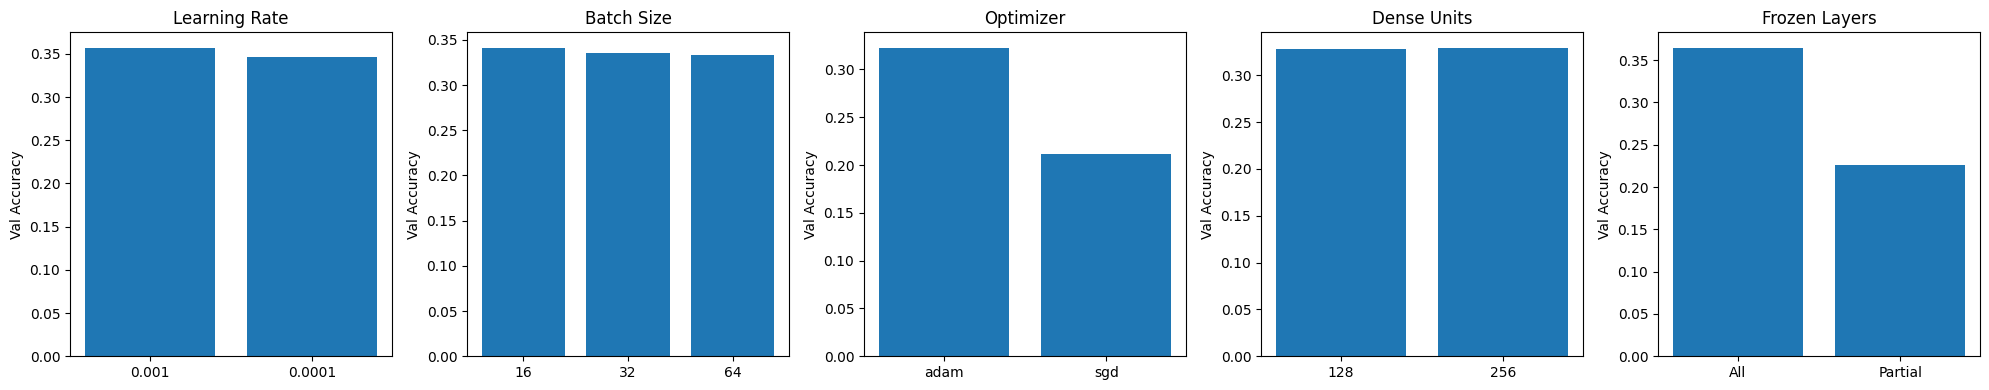

Learning Rate: {0.001: 0.3571000099182129, 0.0001: 0.3467999994754791}
Batch Size: {16: 0.34119999408721924, 32: 0.335099995136261, 64: 0.3330000042915344}
Optimizer: {'adam': 0.32260000705718994, 'sgd': 0.2117999941110611}
Dense Units: {128: 0.32749998569488525, 256: 0.3292999863624573}
Frozen Layers: {False: 0.3646000027656555, True: 0.226500004529953}


In [24]:
fig, axs = plt.subplots(1, 5, figsize=(20,4))

axs[0].bar([str(k) for k in lr_results], lr_results.values()); axs[0].set_title('Learning Rate')
axs[1].bar([str(k) for k in batch_results], batch_results.values()); axs[1].set_title('Batch Size')
axs[2].bar(opt_results.keys(), opt_results.values()); axs[2].set_title('Optimizer')
axs[3].bar([str(k) for k in dense_results], dense_results.values()); axs[3].set_title('Dense Units')
axs[4].bar(['All' if not k else 'Partial' for k in frozen_results], frozen_results.values()); axs[4].set_title('Frozen Layers')

for ax in axs:
    ax.set_ylabel('Val Accuracy')

plt.tight_layout()
plt.savefig("images/hyperparameter_study.png", dpi=300)
plt.show()

print("Learning Rate:", lr_results)
print("Batch Size:", batch_results)
print("Optimizer:", opt_results)
print("Dense Units:", dense_results)
print("Frozen Layers:", frozen_results)

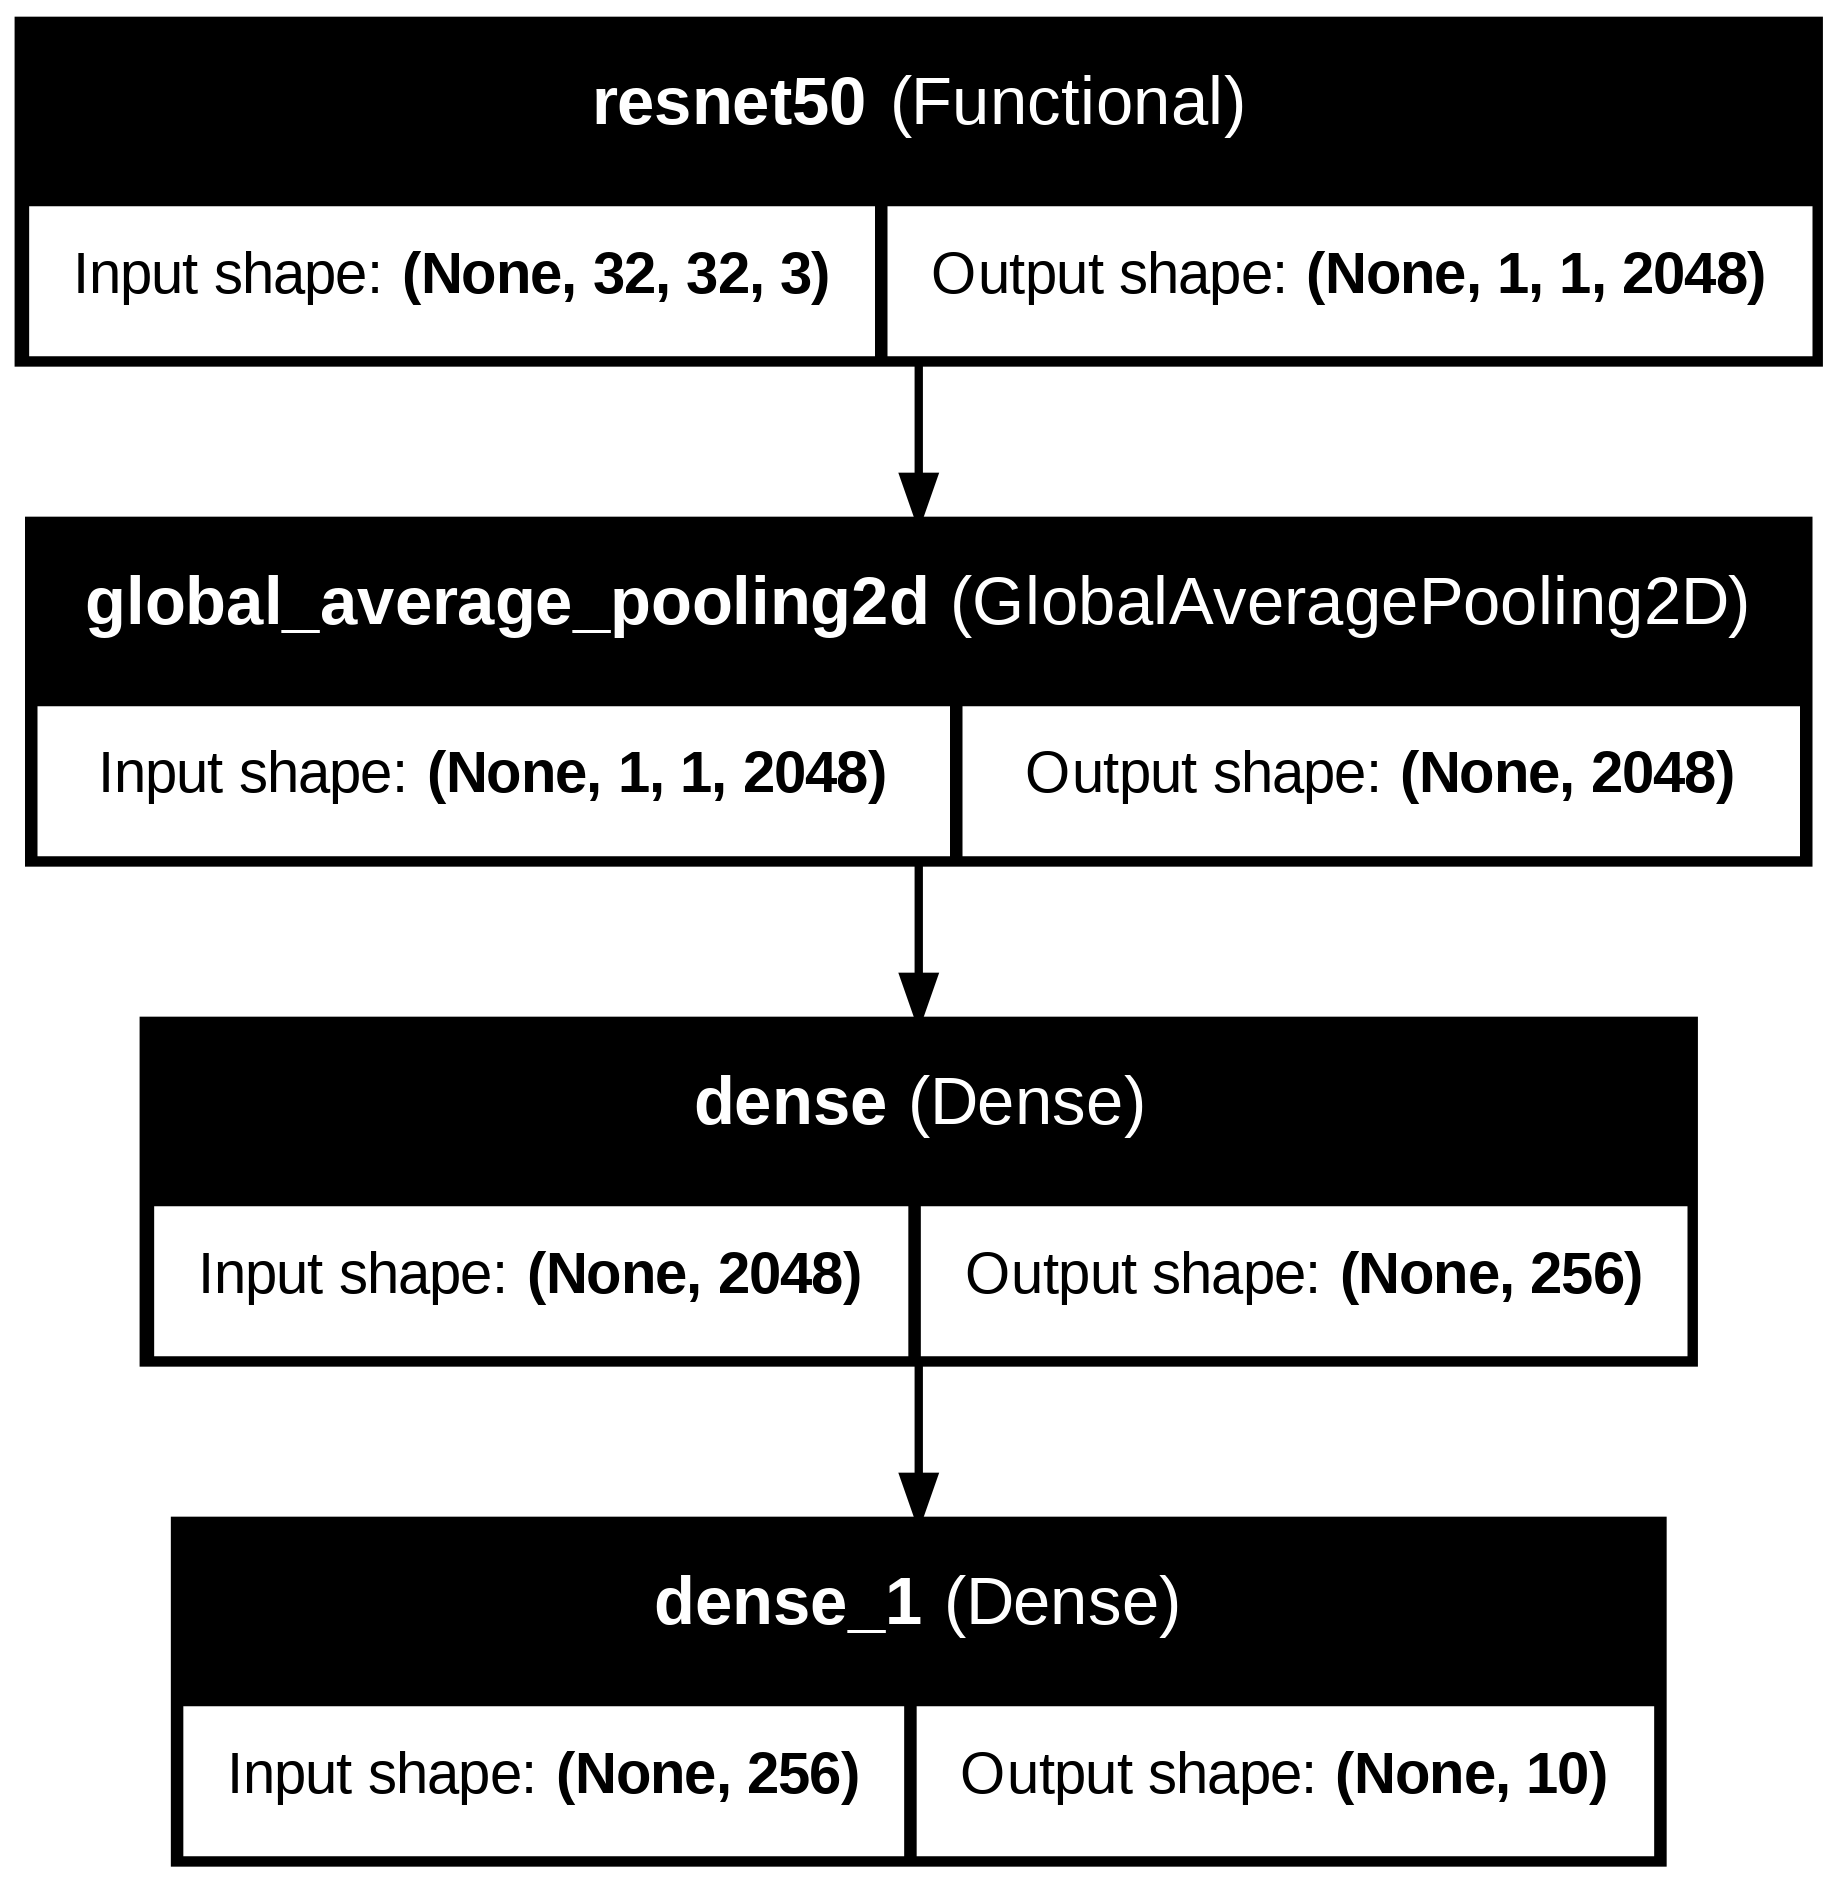

In [27]:
!pip install pydot -q
tf.keras.utils.plot_model(model, to_file="images/cnn_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

In [28]:
shutil.make_archive("images", 'zip', "images")
print("Saved: images.zip")

Saved: images.zip
